In [1]:
from astropy.table import Table, unique, hstack, vstack, join
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
import pandas as pd

from tqdm import tqdm

import numpy as np

from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from hyperfit.linfit import LinFit
import corner
import sys
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import profile_histogram

# Read in catalogs

In [3]:
# ## Read in DR2 TF catalog
SGA = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v5a.fits')
SGA['SGA_ID'] = SGA['SGA_ID'].astype(int)

# ## Read in rotation curve parameters
curves= Table.read('/pscratch/sd/n/nravi/BTFR/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits')

## Read in SGA_IDs for each of the MaNGA objects
manga_crossmatch= Table.read('/global/homes/s/sgmoore1/DESI_SGA/MaNGA/MaNGA_SGA_crossmatch_2022-06-28.txt', format='ascii.commented_header')

## Combine to get SGA_IDs for each rotation curve
manga_curves = join(curves, manga_crossmatch['SGA_ID', 'plateifu'], keys=['plateifu'])

# ## Combine rotation curves with SGA
SGA_manga = join(SGA, manga_curves, keys='SGA_ID')
len(SGA_manga)

833

In [4]:
## Apply quality cuts to rotation curves

SGA_manga = SGA_manga[(SGA_manga['alpha']<=99) & (SGA_manga['v_max_err']/SGA_manga['v_max']<=2) 
    & (SGA_manga['v_max']<1000) & (SGA_manga['v_max']>10) & SGA_manga['JOHN_VI'].mask]
len(SGA_manga)

755

In [5]:
## Compute total surface brightness within 26th isophote
# SGA_manga['SB'] = SGA_manga['R_MAG_SB26_CORR'] + 2.5*np.log10(np.pi*SGA_manga['SMA_SB26']**2*SGA_manga['BA'])
SGA_manga['SB'] = SGA_manga['R_MAG_SB26_CORR'] + 2.5*np.log10(np.pi*SGA_manga['SMA_SB26']**2)


### Compute physical radius for R26 in kpc/h
SGA_manga['R26_kpc'] = 0.5*SGA_manga['D26_kpc']

# Look at MaNGA measurements compared to DESI

## Comparing $R_{\text{turn}}$ to $R_{26}$

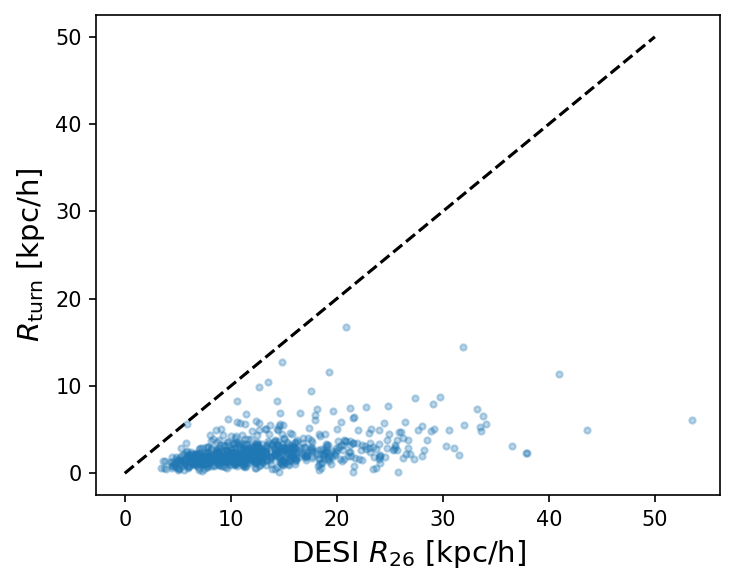

In [35]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['R26_kpc'], SGA_manga['r_turn'], alpha=0.3, fmt='.')

plt.plot((0,50), (0,50), 'k--')

plt.xlabel(r'DESI $R_{26}$ [kpc/h]', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$ [kpc/h]', fontsize=14)

# plt.ylim(0,10)

plt.show();

In [36]:
large_rturn = SGA_manga[SGA_manga['r_turn'] > SGA_manga['R26_kpc']]['SGA_ID', 'plateifu', 'r_turn', 'R26_kpc', 'v_max', 'v_max_err', 'V_0p4R26', 'Z_DESI_CMB', 'D26', 'RA', 'DEC', 'SB', 'R_MAG_SB26', 'R_ABSMAG_SB26']
large_rturn

SGA_ID,plateifu,r_turn,R26_kpc,v_max,v_max_err,V_0p4R26,Z_DESI_CMB,D26,RA,DEC,SB,R_MAG_SB26,R_ABSMAG_SB26
,,,kpc,,,,,,,,,,
int64,str32,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float32,float64


In [37]:
print(large_rturn['SGA_ID'], large_rturn['plateifu'])

SGA_ID
------ plateifu
--------


In [38]:
### Temporarily let's remove those objects, because something is strange with them
SGA_manga = SGA_manga[SGA_manga['r_turn'] < SGA_manga['R26_kpc']]
len(SGA_manga)

750

## Comparing $V_{\text{max}}$ to $V_{R_{26}}$

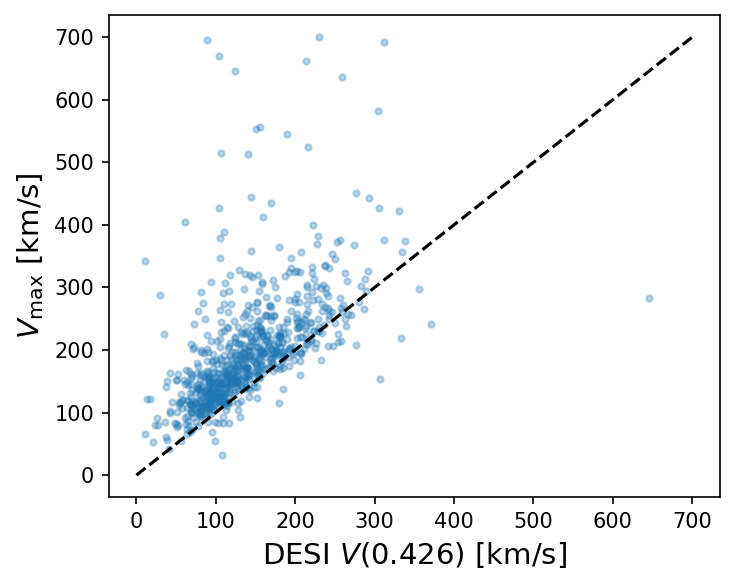

In [39]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['V_0p4R26'], SGA_manga['v_max'], alpha=0.3, fmt='.')

plt.plot((0,700), (0,700), 'k--', zorder=10)

plt.xlabel(r'DESI $V (0.426)$ [km/s]', fontsize=14)
plt.ylabel(r'$V_{\text{max}}$ [km/s]', fontsize=14)

# plt.ylim(0,40)
# plt.ylim(0,20)

plt.show();

# Plot some rotation curves

In [40]:
def v_Vmax(Rturn, alpha, r):
    v = r /((Rturn**alpha + r**alpha)**(1/alpha))
    return v

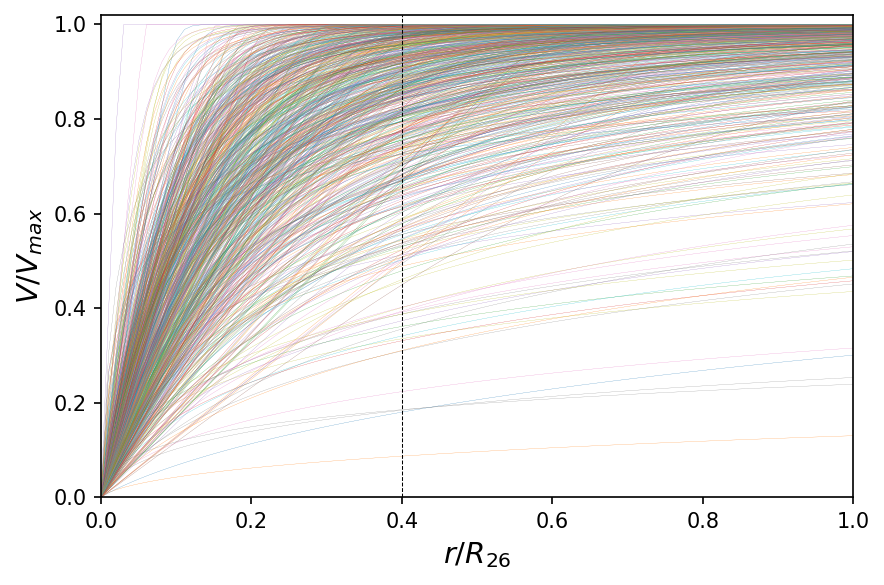

In [41]:
r = np.linspace(0,1,100)

plt.figure(figsize=(6,4), tight_layout=True, facecolor='none', dpi=150)

for i in range(0,len(SGA_manga)):
    vel = v_Vmax((SGA_manga['r_turn'][i]/SGA_manga['R26_kpc'][i]), SGA_manga['alpha'][i], r)
    plt.plot(r, vel, lw=0.1)

plt.axvline(x=0.4, color='k', lw=0.5, ls='dashed')
# plt.plot([17,22], A*np.array([17,22]) + (B + v_median), 'k')

plt.xlabel(r'$r/R_{26}$', fontsize=14)
plt.ylabel(r'$V/V_{max}$', fontsize=14)
plt.xlim(0,1)
plt.ylim(0,1.02)
plt.show();

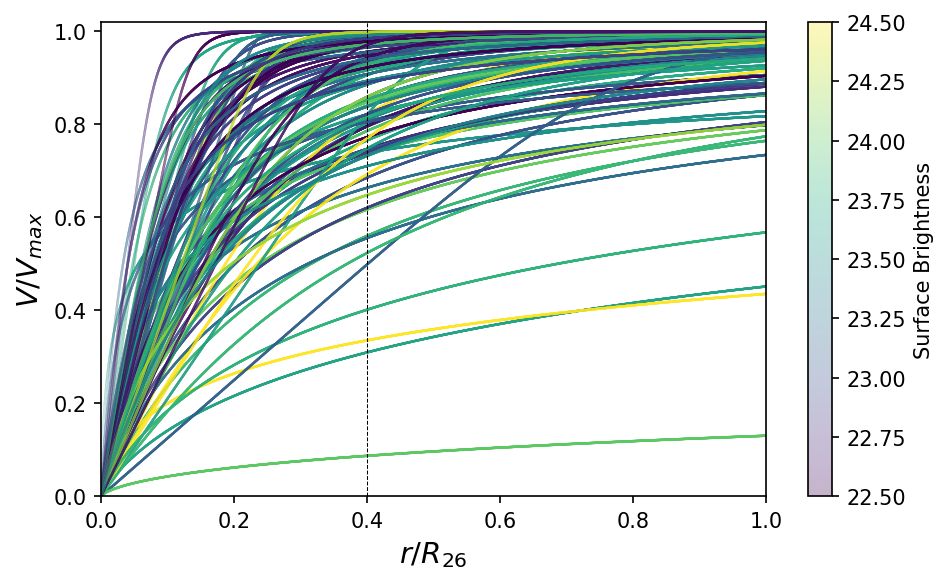

In [45]:
r = np.linspace(0,1,10000)

plt.figure(figsize=(6.5,4), tight_layout=True, facecolor='none', dpi=150)

for i in range(0,100):
    vel = v_Vmax((SGA_manga['r_turn'][i]/SGA_manga['R26_kpc'][i]), SGA_manga['alpha'][i], r)
    plt.scatter(r, vel, s=0.02, c=np.full(len(r), SGA_manga['SB'][i]), vmin=22.5, vmax=24.5, alpha=0.3)

plt.axvline(x=0.4, color='k', lw=0.5, ls='dashed')
plt.colorbar(label='Surface Brightness')
plt.xlabel(r'$r/R_{26}$', fontsize=14)
plt.ylabel(r'$V/V_{max}$', fontsize=14)
plt.xlim(0,1)
plt.ylim(0,1.02)
plt.show();

## According to these curves, how many galaxies are we actually measuring $V_{\text{max}}$ for?

In [46]:
v_vmax_0p4R26 = v_Vmax((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.4)

print(f'V/Vmax> 99% {np.sum(v_vmax_0p4R26>0.99)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.99)} of {len(v_vmax_0p4R26)})')
print(f'V/Vmax> 95% {np.sum(v_vmax_0p4R26>0.95)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.95)} of {len(v_vmax_0p4R26)})')
print(f'V/Vmax> 90% {np.sum(v_vmax_0p4R26>0.9)/len(v_vmax_0p4R26):.2f} ({np.sum(v_vmax_0p4R26>0.9)} of {len(v_vmax_0p4R26)})')

V/Vmax> 99% 0.13 (97 of 750)
V/Vmax> 95% 0.33 (247 of 750)
V/Vmax> 90% 0.49 (367 of 750)


## How does the V from the rotation curve at $r=0.4R_{26}$ compare to our measurement?

In [47]:
SGA_manga['V_0p4R26_pred'] = v_Vmax((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.4)*SGA_manga['v_max']

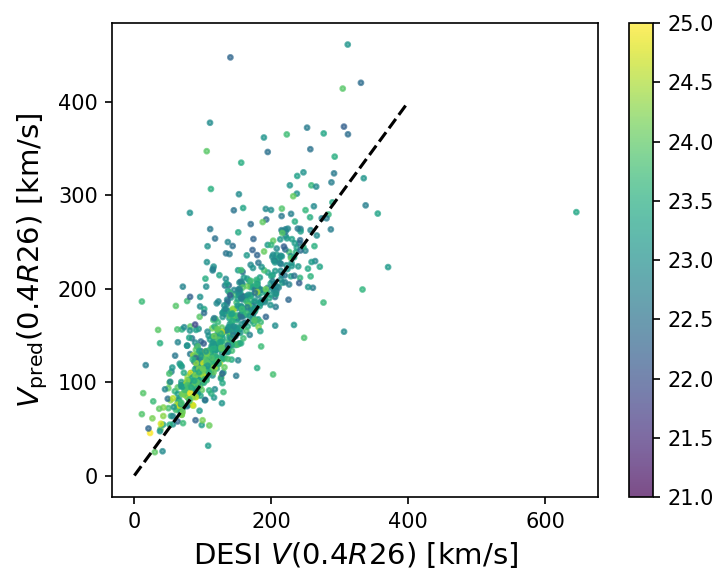

In [63]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(SGA_manga['V_0p4R26'], SGA_manga['V_0p4R26_pred'], c=SGA_manga['SB'], vmin=21, vmax=25, alpha=0.7, s=5)

plt.plot((0,400), (0,400), 'k--', zorder=10)
plt.colorbar()
plt.xlabel(r'DESI $V (0.4R26)$ [km/s]', fontsize=14)
plt.ylabel(r'$V_{\text{pred}} (0.4R26)$ [km/s]', fontsize=14)

# plt.ylim(0,40)
# plt.ylim(0,20)

plt.show();

# Correlations between rotation curve parameters and surface brightness

/global/u1/s/sgmoore1/DESI_SGA/TF/help_functions.py:68: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


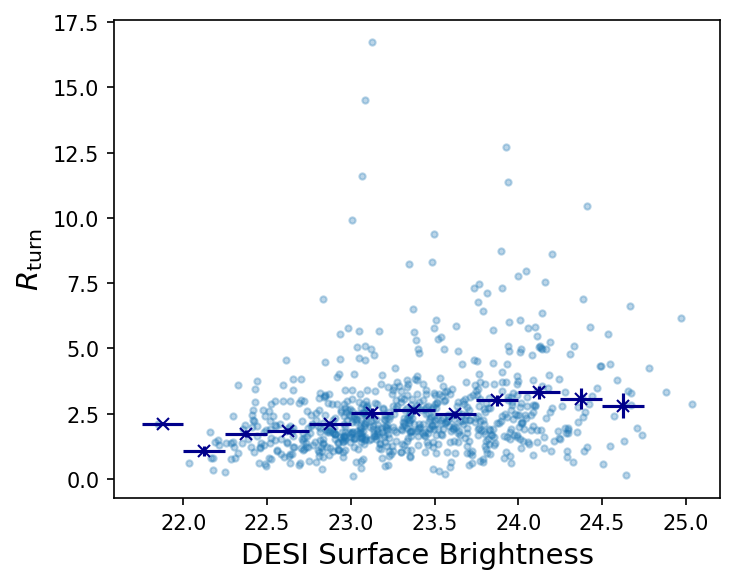

In [49]:
sbins = np.arange(21,25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['r_turn'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['r_turn'],
    sbins,
    weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

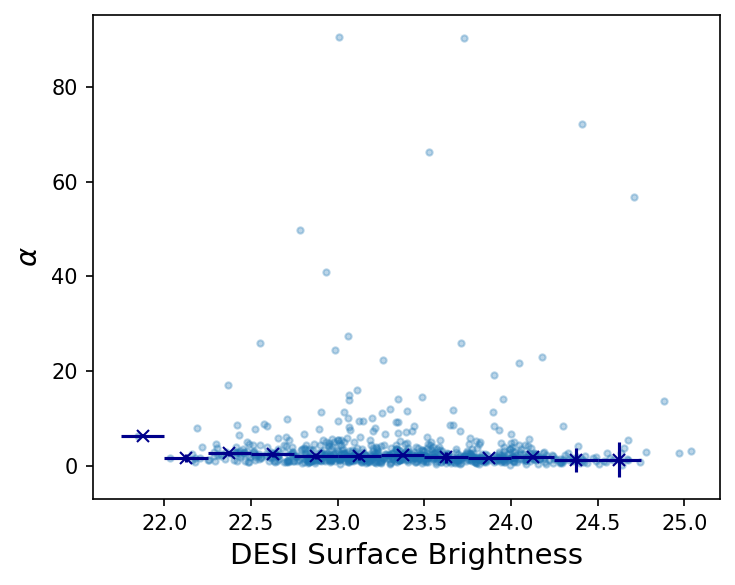

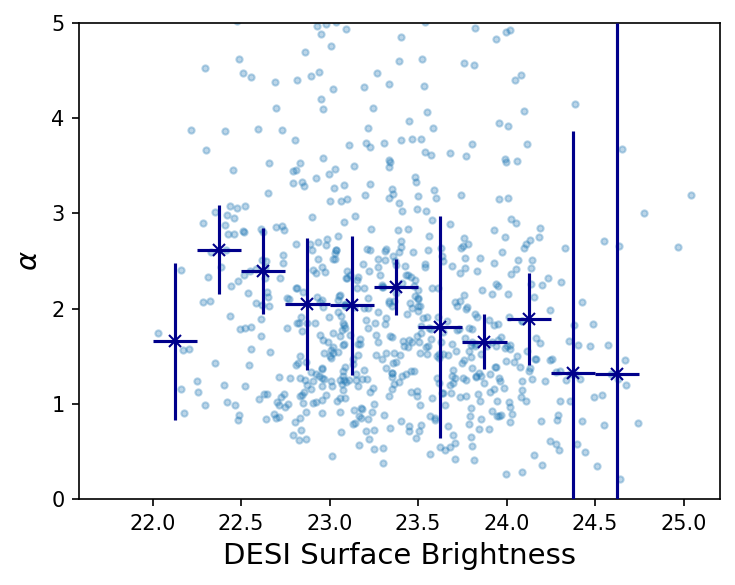

In [50]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['alpha'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['alpha'],
    sbins,
    stat='median',)
    # weighted=False)

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5)

plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
# plt.xlim(21.5,17.5)
plt.ylim(0,5)

plt.show();

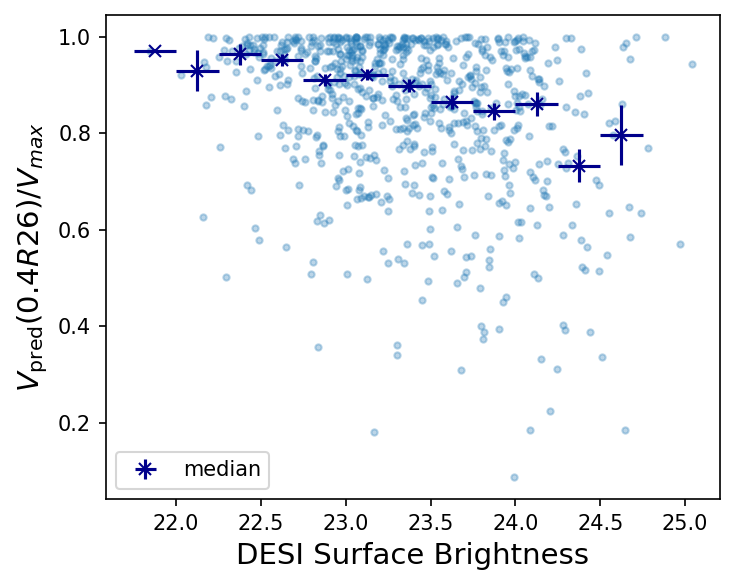

In [51]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['V_0p4R26_pred']/SGA_manga['v_max'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['V_0p4R26_pred']/SGA_manga['v_max'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5, label='median')

plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$V_{\text{pred}}(0.4R26)/V_{max}$ ', fontsize=14)
plt.legend()
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

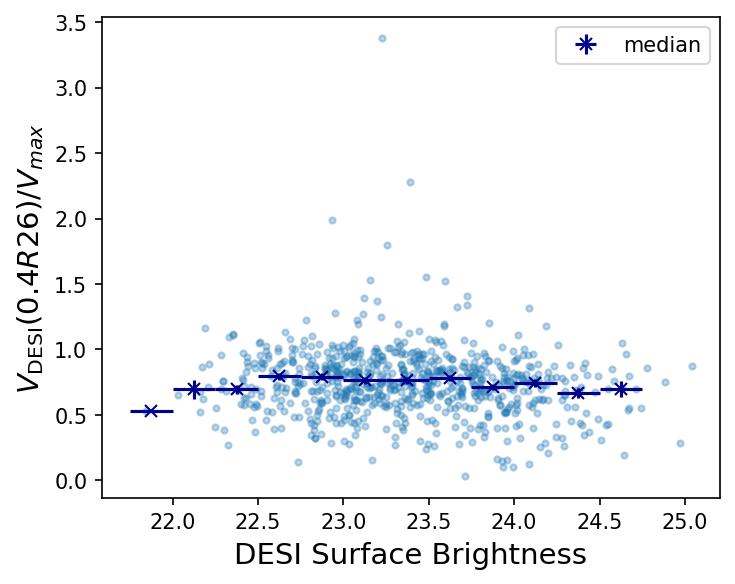

In [52]:
plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['V_0p4R26']/SGA_manga['v_max'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['V_0p4R26']/SGA_manga['v_max'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$V_{\text{DESI}}(0.4R26)/V_{max}$ ', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

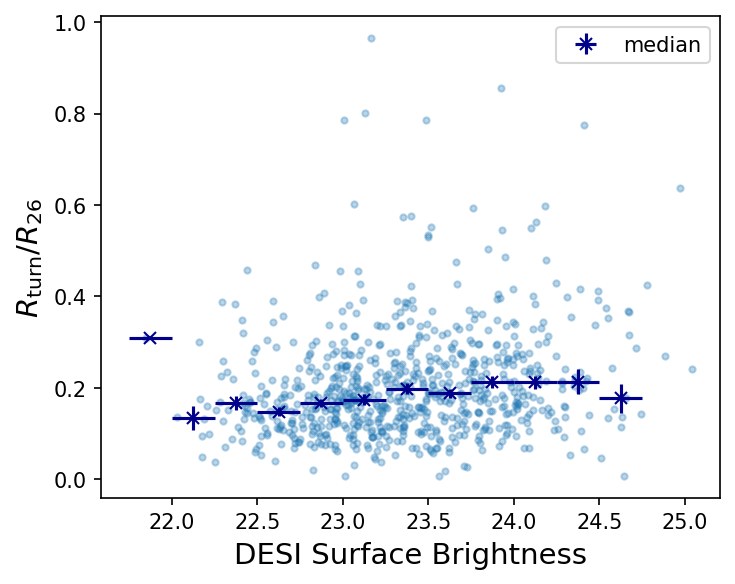

In [54]:
sbins = np.arange(21, 25, 0.25)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.errorbar(SGA_manga['SB'], SGA_manga['r_turn']/SGA_manga['R26_kpc'], alpha=0.3, fmt='.')

N, y_avg, y_std = profile_histogram(
    SGA_manga['SB'],
    SGA_manga['r_turn']/SGA_manga['R26_kpc'],
    sbins,
    stat='median')

plt.errorbar(sc, y_avg,xerr=ds, yerr=y_std,fmt='x', color='darkblue', zorder=5, label='median')
plt.legend()
plt.xlabel(r'DESI Surface Brightness', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}/R_{26}$', fontsize=14)
# plt.xlim(21.5,17.5)
# plt.ylim(0,10)

plt.show();

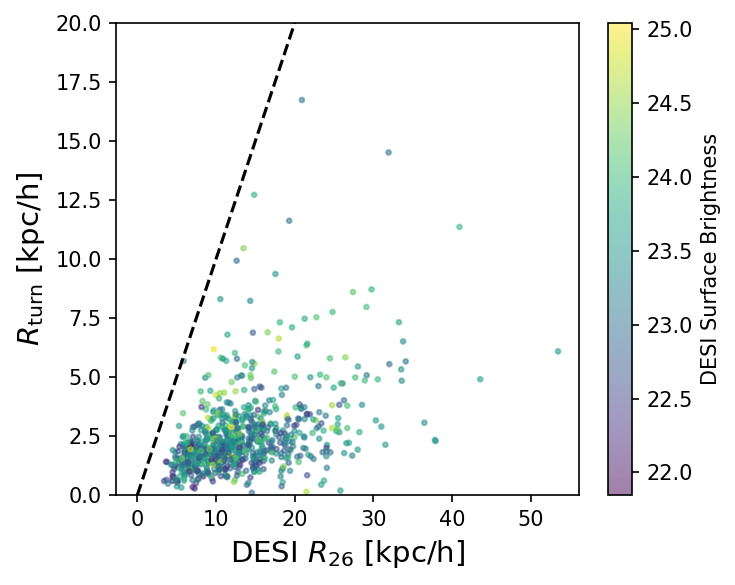

In [55]:
sbins = np.arange(16,22, 0.5)
ds = 0.5*np.diff(sbins)
sc = 0.5*(sbins[1:] + sbins[:-1])

plt.figure(figsize=(5,4), tight_layout=True, facecolor='none', dpi=150)

plt.scatter(SGA_manga['R26_kpc'], SGA_manga['r_turn'], c=SGA_manga['SB'], alpha=0.5, s=5)

plt.plot((0,50), (0,50), 'k--')

plt.xlabel(r'DESI $R_{26}$ [kpc/h]', fontsize=14)
plt.ylabel(r'$R_{\text{turn}}$ [kpc/h]', fontsize=14)
plt.colorbar(label='DESI Surface Brightness')
plt.ylim(0,20)

plt.show();

# Look at slope of rotation curves at a fixed radius

In [56]:
def rot_curve_slope(Rturn, alpha, r):
    slope = Rturn**alpha * ((Rturn**alpha + r**alpha)**(-(1+alpha)/alpha))
    return slope

In [57]:
SGA_manga['slope_0p1R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.1)
SGA_manga['slope_0p05R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.05)
SGA_manga['slope_0p2R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.2)
SGA_manga['slope_0p01R26'] = rot_curve_slope((SGA_manga['r_turn']/SGA_manga['R26_kpc']), SGA_manga['alpha'], 0.01)

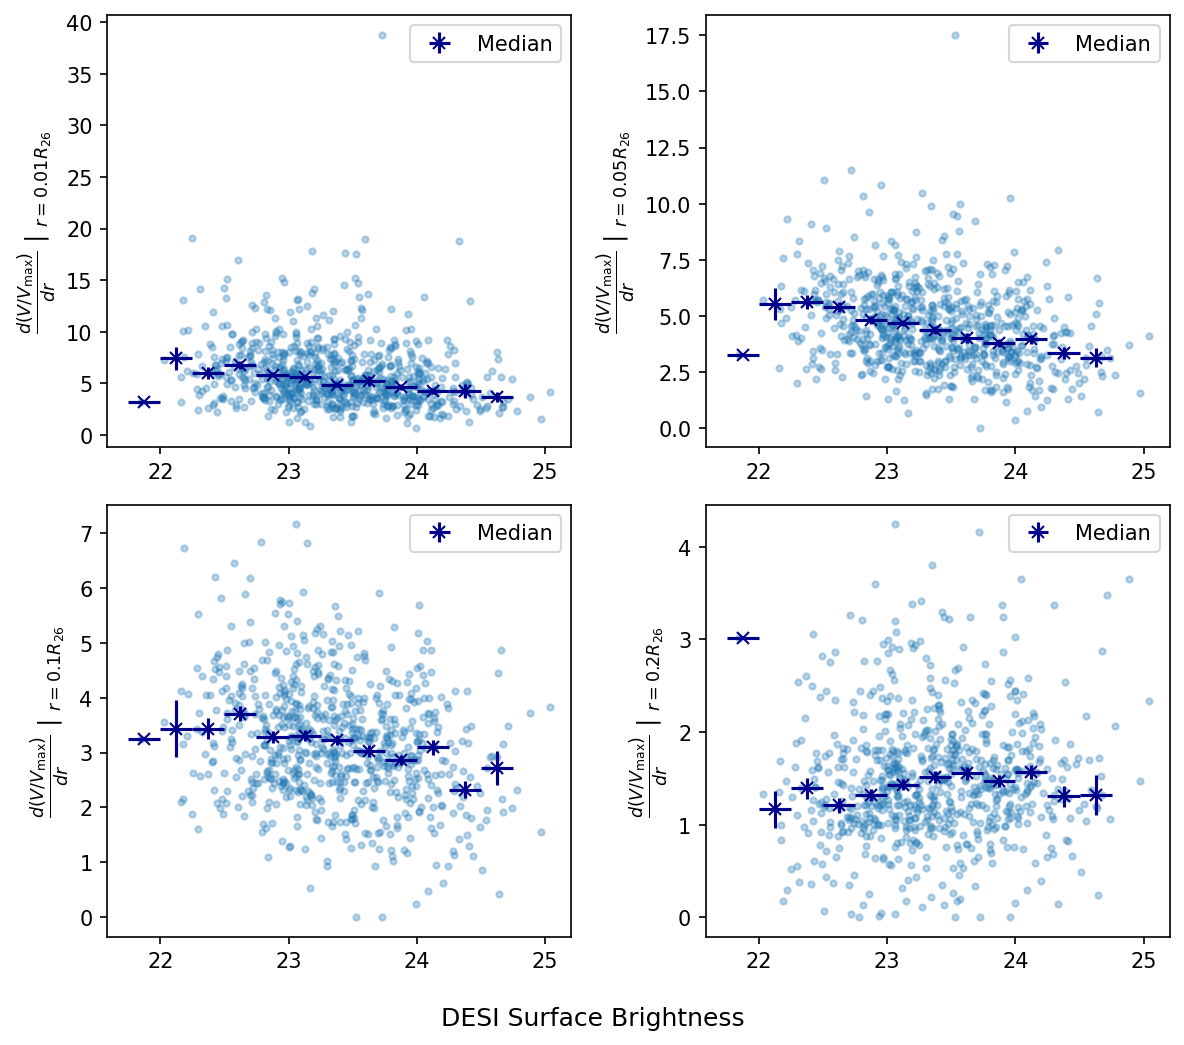

In [59]:
sbins = np.arange(21, 25, 0.25)
ds = 0.5 * np.diff(sbins)
sc = 0.5 * (sbins[1:] + sbins[:-1])

slope_cols = ['slope_0p01R26','slope_0p05R26','slope_0p1R26','slope_0p2R26']
radii = ['0.01', '0.05', '0.1', '0.2']

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    tight_layout=True,
    facecolor='none',
    dpi=150
)

for ax, slope_col, radius in zip(axes.flat, slope_cols, radii):

    ax.errorbar(SGA_manga['SB'], SGA_manga[slope_col], alpha=0.3, fmt='.')

    N, y_avg, y_std = profile_histogram(SGA_manga['SB'],
                                        SGA_manga[slope_col],
                                        sbins,
                                        stat='median')

    ax.errorbar(sc, y_avg, xerr=ds, yerr=y_std, fmt='x', color='darkblue', zorder=5, label='Median')
    ax.legend()
    ax.set_ylabel(r'$\frac{d (V/V_{\mathrm{max}})}{dr}' r'\mid_{r=' + radius + r'R_{26}}$',fontsize=12)

fig.supxlabel('DESI Surface Brightness', fontsize=12)
plt.show()